# Setting up HugginFace - Importing basics and Login.

In [ ]:
import os
HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
from huggingface_hub import login
login(token=HF_TOKEN)

In [3]:
!hf auth whoami

user:  RonnieSDas


"https://huggingface.co/spaces/mrdbourke/trashify_demo_v4" - Final Project Demo looks like the one below:

In [ ]:
from IPython.display import HTML 

HTML("""
<iframe
    src="https://mrdbourke-trashify-demo-v4.hf.space"
    frameborder="0"
    width="850"
    height="1150"
></iframe>
""")

In [ ]:
import datasets
import gradio as gr
import torchmetrics 
import pycocotools
import random
import numpy as np
import torch
import transformers
from pprint import pprint


#Check package versions:
print(f"USING VERSIONS - \ttransformers : {transformers.__version__}, \t datasets : {datasets.__version__}, \t torch : {torch.__version__}, \t torchmetrics : {torchmetrics.__version__}")

USING VERSIONS - 	transformers : 5.2.0, 	 datasets : 4.5.0, 	 torch : 2.5.1+cu121, 	 torchmetrics : 1.8.2


NOTE: A tool for drawing boxes on images for object boundary detection is [Prodigy](https://prodi.gy/features/computer-vision)

# Loading the dataset

In [ ]:
from datasets import load_dataset
load_dataset? #Basic class definition

In [20]:
dataset = load_dataset(path = "mrdbourke/trashify_manual_labelled_images")
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [56]:
print(dataset['train']) # type(dataset) -> datasets.dataset_dict.DatasetDict | isinstance(dataset, datasets.dataset_dict.DatasetDict) -> True
type(dataset)

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
})


datasets.dataset_dict.DatasetDict

In [ ]:
pprint(dataset['train'][0]) #Viewing a sample's features

{'annotations': {'area': [135381.078125, 1039532.4375],
                 'bbox': [[523.7000122070312,
                           545.0999755859375,
                           402.79998779296875,
                           336.1000061035156],
                          [10.399999618530273,
                           163.6999969482422,
                           943.4000244140625,
                           1101.9000244140625]],
                 'category_id': [1, 0],
                 'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
                               '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
                 'image_id': [292, 292],
                 'iscrowd': [0, 0]},
 'image': <PIL.Image.Image image mode=RGB size=960x1280 at 0x7B01701D5F40>,
 'image_id': 292,
 'image_source': 'manual_taken_photo',
 'label_source': 'manual_prodigy_label'}


In [115]:
print(type(dataset['train'].features))
pprint(dataset['train'].features) #Viewing all samples' features

<class 'datasets.features.features.Features'>
{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}


In [117]:
print(type(dataset['train'].features['annotations']))
pprint(dataset['train'].features['annotations']) # Accessing a specific key in the 'dataset["train"]' dict.
print('\n', type(dataset['train'].features['annotations'])) # Turns out each key is a dict as well. A nested dict structure.
print('\n', dataset['train'].features['annotations'].keys()) # Set of all keys inside the dict 'annotations' which happens to be a key of the dict 'dataset['train']'
print('\n', dataset['train'].features['annotations']['area']) # Accessing a specific key in the 'annotations' dict.

<class 'dict'>
{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Value('string')),
 'image_id': List(Value('int64')),
 'iscrowd': List(Value('int64'))}

 <class 'dict'>

 dict_keys(['file_name', 'image_id', 'category_id', 'bbox', 'iscrowd', 'area'])

 List(Value('float32'))


In [ ]:
dataset['train'][2]['annotations']['bbox'][0] # This array gives us the coordinates of a single bounding box in the format XYWH.

[349.5, 677.2000122070312, 210.89999389648438, 376.0]

X is the x-coordinate of the top left corner of the box (349.5). \
Y is the y-coordinate of the top left corner of the box (677.2000122070312).\
W is the width of the box (210.89999389648438).\
H is the height of the box (376.0).

In [138]:
categories = dataset['train'].features['annotations']['category_id']
print(type(categories), dir(categories), "\n")
print(type(categories.feature), "\n")
print(categories)
print(categories.feature)
print(categories.feature.names)

<class 'datasets.features.features.List'> ['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_type', 'feature', 'id', 'length', 'pa_type'] 

<class 'datasets.features.features.ClassLabel'> 

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])
['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']


In [143]:
# Creating a mapping from numbers to labels
id2label = {i:class_name for i, class_name in enumerate(categories.feature.names)}
print(id2label.items())
label2id = {value:key for key, value in id2label.items()}
print(label2id.items())

dict_items([(0, 'bin'), (1, 'hand'), (2, 'not_bin'), (3, 'not_hand'), (4, 'not_trash'), (5, 'trash'), (6, 'trash_arm')])
dict_items([('bin', 0), ('hand', 1), ('not_bin', 2), ('not_hand', 3), ('not_trash', 4), ('trash', 5), ('trash_arm', 6)])


In [145]:
# Creating a colour palette
# Make colour dictionary
colour_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

pprint(colour_palette)

{'bin': (0, 0, 224),
 'hand': (148, 0, 211),
 'not_bin': (255, 80, 80),
 'not_hand': (255, 80, 80),
 'not_trash': (255, 80, 80),
 'trash': (0, 255, 0),
 'trash_arm': (255, 140, 0)}


We’ll just have to write a small function to normalize our colour values from [0, 255] to [0, 1] \
 (matplotlib expects our colour values to be between 0 and 1).


[('bin', (0.0, 0.0, 0.8784313725490196)),
 ('not_bin', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('hand', (0.5803921568627451, 0.0, 0.8274509803921568)),
 ('not_hand', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash', (0.0, 1.0, 0.0)),
 ('not_trash', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash_arm', (1.0, 0.5490196078431373, 0.0))]

 <class 'list'>


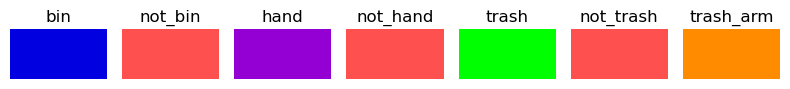

In [167]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize RGB values between 0-1 range:
def normalize_rgb(rgb_tuple):
    return tuple(x/255 for x in rgb_tuple)

# Turn colors into normalized RGB values for matplotlib
colors_and_labels_rgb  = [(key, normalize_rgb(value)) for (key, value) in colour_palette.items()]
pprint(colors_and_labels_rgb) 
print('\n',type(colors_and_labels_rgb))

# Create figure and axis
fig, ax = plt.subplots(1, 7, figsize = (8,1))

# Flatten the axis array for easier iteration
ax = ax.flatten()

# Plot each color square
for idx, (label, color) in enumerate(colors_and_labels_rgb):
    ax[idx].add_patch(plt.Rectangle(xy=(0, 0), 
                                    width=1, 
                                    height=1, 
                                    facecolor=color))
    ax[idx].set_title(label)
    ax[idx].set_xlim(0, 1)
    ax[idx].set_ylim(0, 1)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()